# Check if the residual data map is noise-like after PCA

In this example, we perform a quick examination on map data using the 2021 L-band map. The PCA routine removes modes that are dominant by foregrounds and systematics, which then (hopefully) gives a residual map that behaves like thermal noise. This notebook demonstrates a few checks on if the residual map is actually noise-like. Note that these tests are necessary but not sufficient of the map being noise-like, meaning that there can still be residual systematics that pass these tests. These are low-level tests that can be run on single block of data as well as combination of multiple blocks on a patch, for quick analysis of data quality.

## Data read-in and PCA

In [1]:
from meer21cm import PowerSpectrum
import matplotlib.pyplot as plt
import numpy as np
from meer21cm.util import pca_clean, mean_center_signal
from meer21cm.plot import plot_map, plot_projected_map

In [2]:
#file_dir = '/idia/users/jywang/MeerKLASS/calibration2021/level6/0.3/sigma4_count40/re_cali1_round5/'
file_dir = '/Users/zhaotingchen/Desktop/work/sd_stacking/'
fits_file = file_dir+'Nscan961_Tsky_cube_p0.3d_sigma4.0_iter2.fits'
counts_file = file_dir+'Nscan961_Npix_count_cube_p0.3d_sigma4.0_iter2.fits'
#gal_file = '/idia/projects/hi_im/GAMA_DR4/G23TilingCatv11.fits'
gal_file = file_dir+'G23TilingCatv11.fits'
ra_range_MK = (334, 357)
dec_range_MK = (-35, -26.5)
ra_range_GAMA = (339,351)
dec_range_GAMA = (-35,-30)
ps = PowerSpectrum(
    map_file=fits_file,
    counts_file=counts_file,
    beam_model='gaussian',
    beam_type='isotropic',
    band='L', # band and survey will produce some pre-defined cuts to select
    survey='meerklass_2021', # the clean frequency sub-band
    ra_range=ra_range_MK,
    dec_range=dec_range_MK,
)
# read in map_file
ps.read_from_fits()
ps.trim_map_to_range()
MKmap_orig = ps.data.copy()

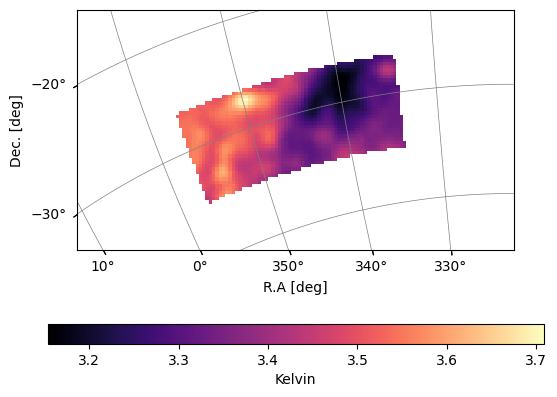

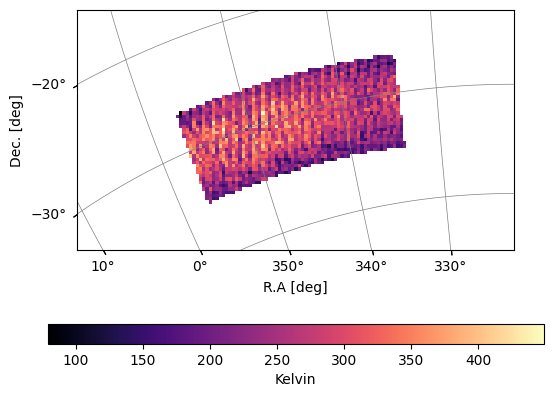

In [3]:
plot_map(ps.data,ps.wproj,W=ps.W_HI,cbar_label='Kelvin')
plot_map(ps.w_HI,ps.wproj,W=ps.W_HI,cbar_label='Kelvin')



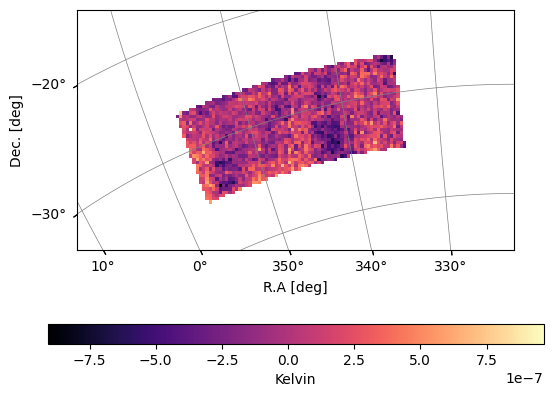

In [4]:
N_fg = 10
MKmap_clean, A_mat = pca_clean(MKmap_orig,N_fg,weights=ps.W_HI,mean_center=True, return_A=True)
cov_orig,_,_,eigenvectors = pca_clean(MKmap_orig,N_fg,weights=ps.W_HI,mean_center=True, return_analysis=True)
plot_map(MKmap_clean,ps.wproj,W=ps.W_HI,cbar_label='Kelvin')

## Test 1: Calculate the frequency covariance of the residual map

If the residual is noise-like, then the covariance matrix should be a diagonal.
We can use `pca_clean` on `return_analysis=True` for calculating the covariance:

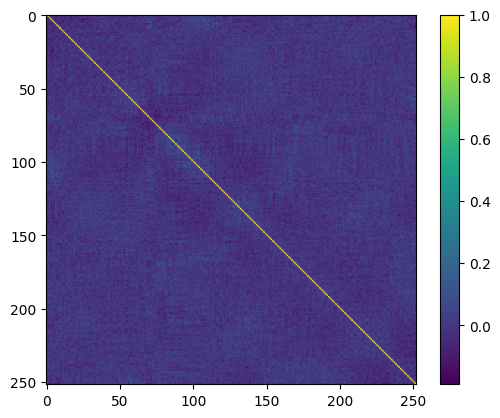

In [5]:
covariance,_,_,_ = pca_clean(MKmap_clean,1,weights=ps.W_HI,mean_center=True, return_analysis=True)
corr_mat = covariance / np.sqrt(np.outer(np.diag(covariance),np.diag(covariance)))
plt.imshow(corr_mat)
plt.colorbar()

## Test 2: Check the projected and the residual map:
The eigenmodes project out a series of component out of the map. You can visualise the maps and see if the main foreground and systematics components are removed.

The projected out components:

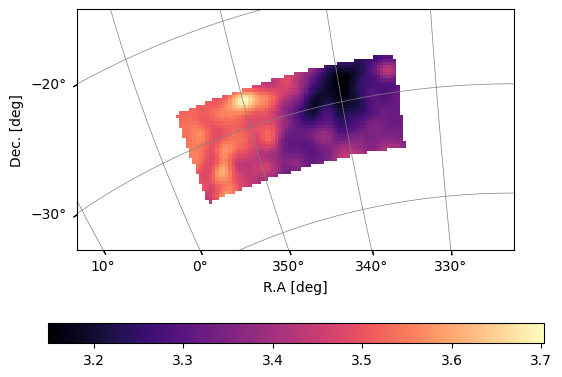

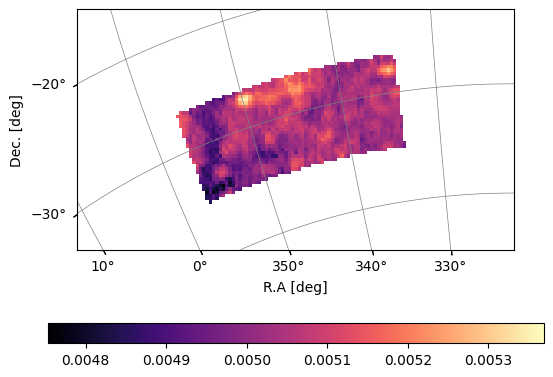

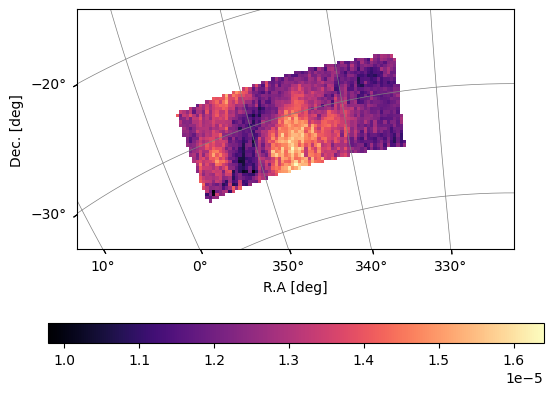

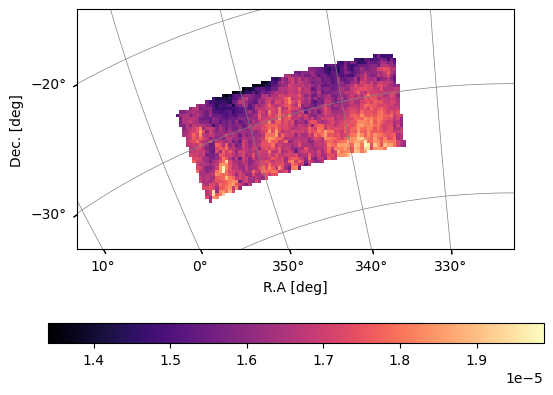

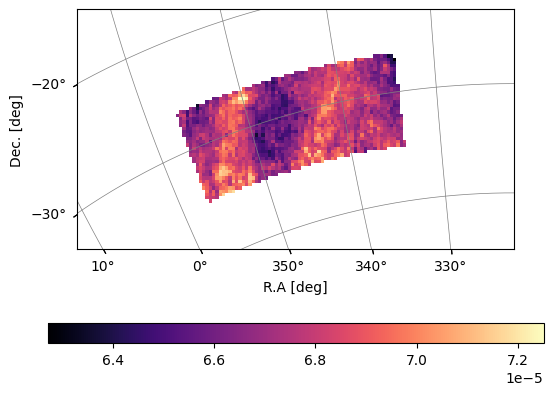

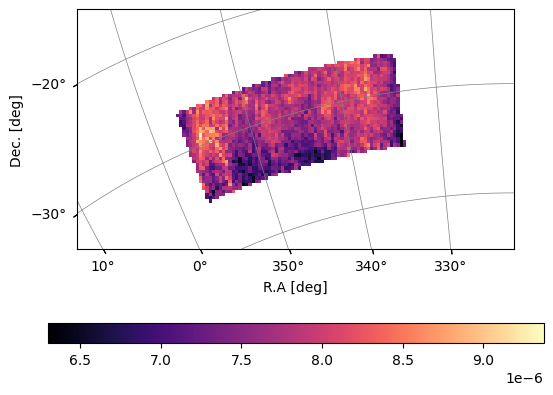

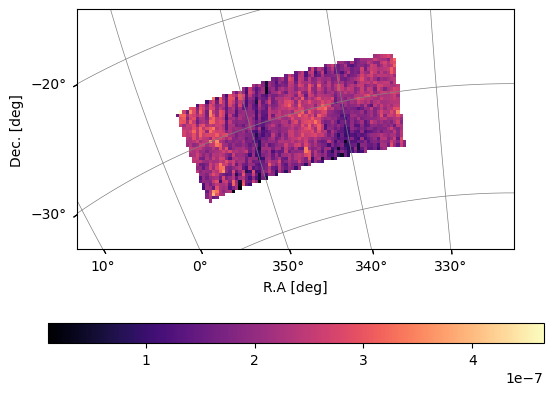

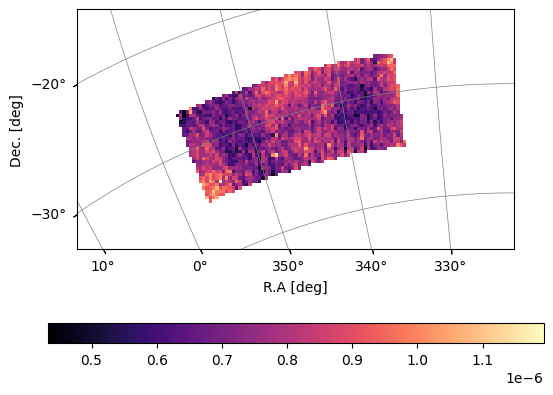

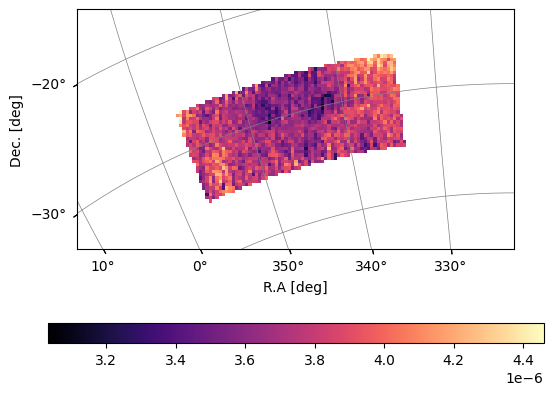

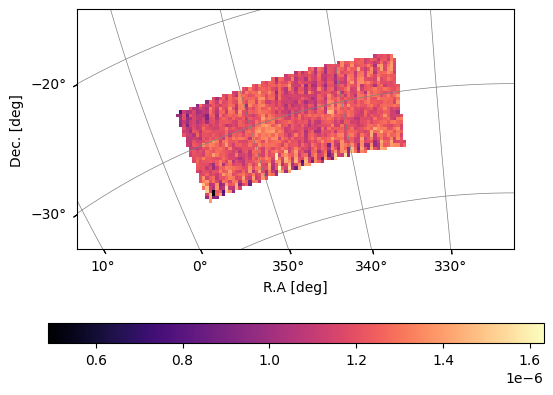

In [6]:
plot_projected_map(A_mat,MKmap_orig,ps.wproj,W=ps.W_HI)

You can see that, the first two modes are smooth foregrounds; The next few modes seem to be systematics-induced structures; Then the map follows the scanning stripes of the map, which is close to noise-like.

You can also verify this by looking at the eigenvectors:

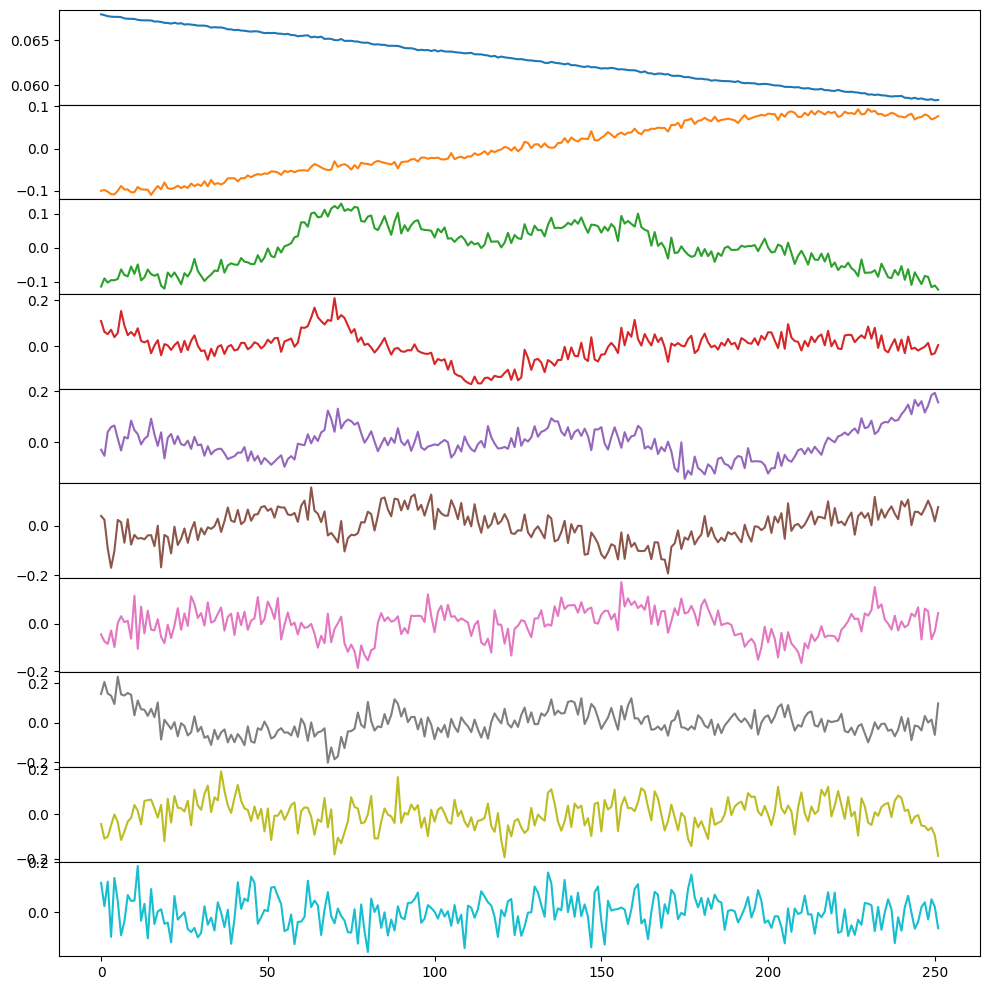

In [7]:
fig,axes = plt.subplots(10,1,figsize=(10,10),sharex=True,gridspec_kw={'hspace':0.0})
for i in range(10):
    axes[i].plot(eigenvectors[:,i],label=f'Eigenvector {i}',color='C'+str(i))
plt.tight_layout()

You can see that after the 8th eigenmode, the eigenvector becomes noise-like.

## Test 3: Test the variance of the map becoming noise-like

If the map data is uncorrelated white-noise, the decrease of the variance of the map for each eigenmode can be exactly calculated, given the mode-mixing matrix. Therefore, given a theoretical noise amplitude, the ratio of the map var and the cleaned theoretical noise amplitude should reach a plateau. If the noise amplitude matches data well, then this plateau should be at 1. You can use `ps.check_is_map_noiselike_using_pca` for checking this:

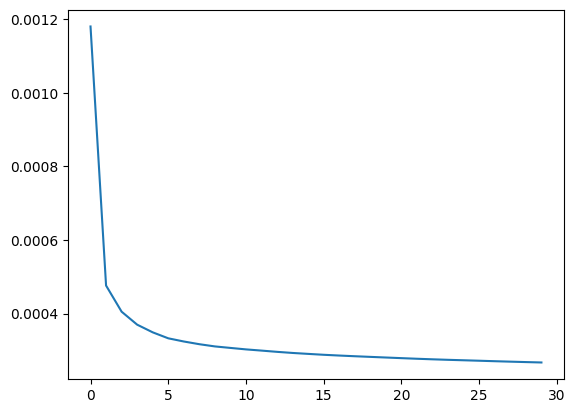

In [ ]:
# remove 20 modes just to see the plateau
_, A_mat_30 = pca_clean(MKmap_orig,30,weights=ps.W_HI,mean_center=True, return_A=True)
# retriete the mean-centered signal
signal_mean_centered = mean_center_signal(MKmap_orig,ps.W_HI)
res, noise = ps.check_is_map_noiselike_using_pca(A_mat_30,data=signal_mean_centered)
plt.plot((res / noise)[1:])

## Bonus: checking if the map variance meets expectation

If you want to check the map variance reaches what you expect from theory, you can calculate a theoretical noise variance based on radiometer equation.

First, you can retrieve a sky model for temperature:

In [9]:
from meer21cm.fg import ForegroundSimulation

fg = ForegroundSimulation(
    hp_nside=256,
    wproj=ps.wproj,
    num_pix_x=ps.num_pix_x,
    num_pix_y=ps.num_pix_y,
    backend="pysm",
    pysm_preset_strings=["d1", "s1", "a1", "c1"],
    coord_system="C",
)
fg_map = fg.fg_wcs_cube(ps.nu)

Subsequently you can add receiver temp, CMB temp to get the system temperature:

In [18]:
from meer21cm.telescope import receiver_temperature_meerkat, cmb_temperature

In [11]:
t_spill = 3.0 # ground spillover
sys_temp = fg_map + receiver_temperature_meerkat(ps.nu) + cmb_temperature(ps.nu) + t_spill

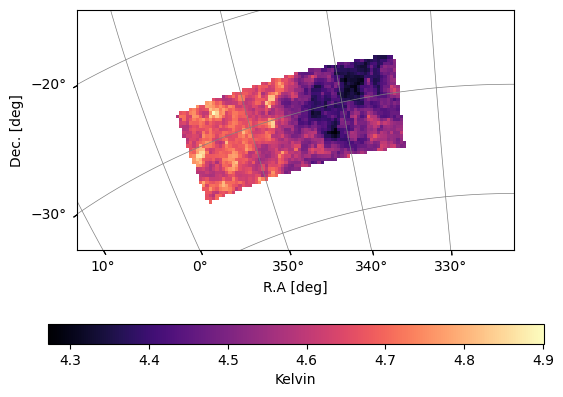

In [12]:
plot_map(fg_map + cmb_temperature(ps.nu)[None,None,:],ps.wproj,W=ps.W_HI,cbar_label='Kelvin')


In [19]:
# for MeerKLASS
time_resolution = 2 # seconds
sigma_N = sys_temp / np.sqrt(2) / np.sqrt(time_resolution * np.diff(ps.nu).mean())

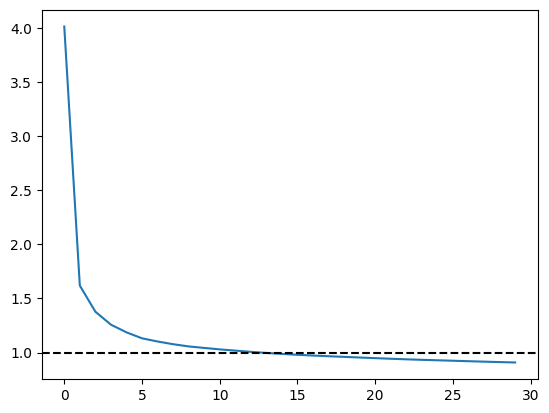

In [21]:
plt.plot((res / noise / sigma_N[ps.W_HI>0].mean()**2))
plt.axhline(1,color='k',linestyle='--')

You can see that indeed the noise level is close to expected.